In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

In [5]:
df = pd.read_csv('../data/nigeria.csv', encoding='latin1')
print(df.shape)
df.head()

(4108, 12)


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
0,2015,1,25.23,29.25,22.06,7.19,0.0,68.26,1.73,2.61,100.86,13.36
1,2015,2,26.16,29.41,22.87,6.54,0.0,73.23,1.42,1.95,100.94,15.37
2,2015,3,25.66,29.02,22.63,6.39,0.0,78.71,1.69,2.33,101.06,15.98
3,2015,4,24.11,27.27,19.92,7.35,0.0,63.66,2.15,3.80,101.09,11.65
4,2015,5,23.40,27.28,18.18,9.10,0.0,59.45,1.88,3.48,101.03,10.40


In [6]:
df.tail()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
4103,2026,86,29.05,32.43,26.69,5.74,2.82,76.60,2.35,3.39,100.58,19.10
4104,2026,87,28.72,31.98,27.14,4.84,5.19,79.61,2.55,3.17,100.64,19.49
4105,2026,88,27.72,29.53,26.21,3.32,1.43,82.83,1.10,1.78,100.61,19.22
4106,2026,89,28.42,31.17,26.36,4.81,0.85,77.73,2.30,3.40,100.53,18.73
4107,2026,90,28.40,31.73,26.32,5.41,5.33,78.79,1.76,2.80,100.59,18.94


Adding the country column

In [7]:
df["COUNTRY"] = "Nigeria"
col = df.pop('COUNTRY')
df.insert(0, "COUNTRY", col)

Inserting a date column that converts, YEAR and DOY to a readable format

In [8]:
df['DATE'] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format='%Y%j')

# saw this is another way to do it
# df['date'] = pd.to_datetime(df['YEAR'].astype(str) + df["DOY"].astype(str).str.zfill(3), format='%Y%j')

Inserting month column for seasonal analysis

In [9]:
df["MONTH"] = df["DATE"].dt.month

Removing nasa's sentinel -999 with nan values

In [10]:
df = df.replace(-999, np.nan)

Counting duplicated rows

In [11]:
df.duplicated().sum()

0

Dropping duplicated rows

In [12]:
df = df.drop_duplicates()

#### Statistical summary

In [13]:
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,DATE,MONTH
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,26.656928,28.914667,24.886461,4.028206,4.213914,85.237040,2.217135,2.903335,100.827205,18.558505,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,21.120000,25.260000,15.170000,1.160000,0.000000,54.400000,0.740000,1.290000,100.380000,9.430000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,25.720000,27.920000,24.100000,3.090000,0.330000,83.930000,1.770000,2.370000,100.710000,17.970000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,26.820000,28.990000,25.100000,3.770000,1.840000,86.350000,2.200000,2.810000,100.820000,18.840000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,27.540000,29.910000,25.860000,4.600000,5.200000,88.500000,2.630000,3.390000,100.950000,19.570000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,29.290000,32.880000,27.790000,11.730000,166.100000,93.790000,4.780000,6.000000,101.350000,21.740000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,1.123335,1.294345,1.396727,1.399169,7.266742,5.446007,0.587191,0.696885,0.165321,1.646313,NaN,3.477046


#### Calculating percentages of missing values in each column

In [14]:
missing = df.isna().sum()
missing_pct = (missing / len(df)) * 100
missing_pct

COUNTRY        0.0
YEAR           0.0
DOY            0.0
T2M            0.0
T2M_MAX        0.0
T2M_MIN        0.0
T2M_RANGE      0.0
PRECTOTCORR    0.0
RH2M           0.0
WS2M           0.0
WS2M_MAX       0.0
PS             0.0
QV2M           0.0
DATE           0.0
MONTH          0.0
dtype: float64

#### Calculating Z-score

In [15]:
cols = ["T2M","T2M_MAX","T2M_MIN","PRECTOTCORR","RH2M","WS2M","WS2M_MAX"]

In [16]:
from scipy.stats import zscore

z_scores = df[cols].apply(zscore)
outliers = (np.abs(z_scores) > 3).sum()
outliers

T2M             10
T2M_MAX          1
T2M_MIN         68
PRECTOTCORR     75
RH2M           128
WS2M             5
WS2M_MAX        10
dtype: int64

In [17]:
outlier_rows = df[(np.abs(z_scores) > 3).any(axis=1)]
len(outlier_rows)

225

#### Outlier Handling Decision

Retained outliers instead of removing them, The reason for this is that theu likely represent real extreme events (e.g., heatwaves, heavy rainfall)
Important for capturing climate variability and trends and invalid values (e.g., -999 sentinel values), were already removed earlier.

If there had been values that were impossible, like a Daily Temperature High of 200 degrees celcius, these whould have been removed. But I did not see such values.

#### Handling Missing Values by filling with previous value

In [18]:
df = df.fillna(method="ffill")

C:\Users\Liya Daniel\AppData\Local\Temp\ipykernel_7380\567689999.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method="ffill")


Another approch to handle missing values, where missing values is greater than 30%

In [19]:
df = df.dropna(thresh=int(len(df.columns) * 0.7))

#### Exporting the dataframe 

In [21]:
df.to_csv("../data/nigeria_clean.csv", index=False)

## Time Series Analysis

#### Monthly average temperature

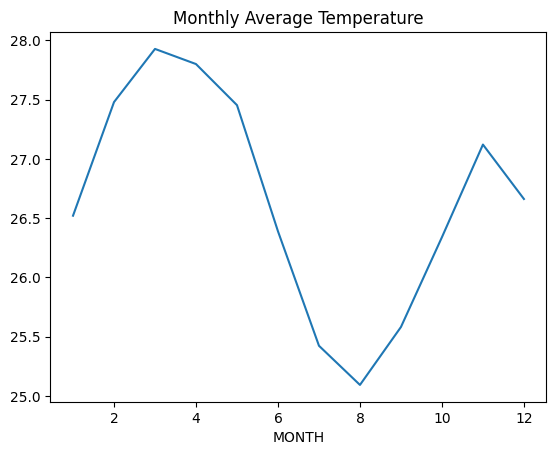

In [24]:
monthly_temp = df.groupby("MONTH")["T2M"].mean()

monthly_temp.plot(kind="line")
plt.title("Monthly Average Temperature")
plt.show()

#### Box plot of Raninfall (prectotcorr)

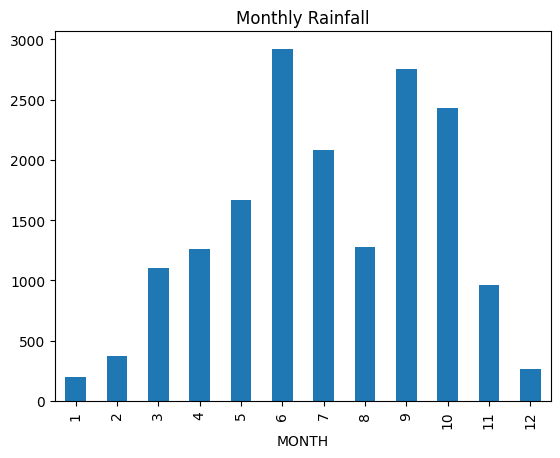

In [25]:
monthly_rain = df.groupby("MONTH")["PRECTOTCORR"].sum()

monthly_rain.plot(kind="bar")
plt.title("Monthly Rainfall")
plt.show()

### Time Series Insights (Temperature & Rainfall)
The warmest months are February to March (Month 2–3), based on the highest average T2M values.  
These months show peak temperatures early in the year, followed by a second smaller peak in November, rather similar to kenya.

The coolest period occurs between June and August (Month 6–8), with the lowest average temperature recorded in July.

The peak rainy season occurs in June (Month 6) with the highest rainfall, followed by a second and third major peaks in September (Month 9) and November (Month 10), respectively. Indicating a bimodal rainfall pattern with two distinct wet seasons.

Data shows a clear seasonal cycle, with hot and relatively drier conditions early in the year, cooler mid-year, and a second wet period toward the end of the year.

## Correlation and Relationship Analysis

#### Heatmap of correlations across all numeric columns

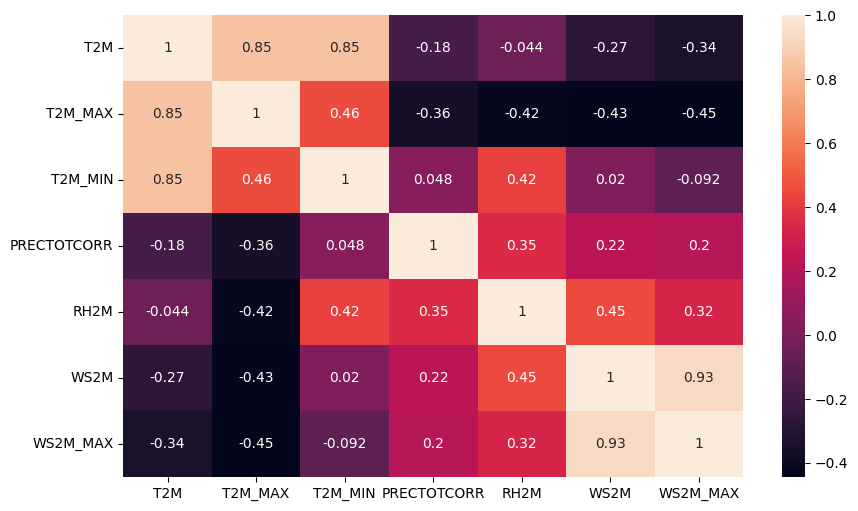

In [26]:
plt.figure(figsize=(10,6))
sns.heatmap(df[cols].corr(), annot=True)
plt.show()

#### Scatter Plot (Mean Temperatue vs Relative Humidity)

<Axes: xlabel='T2M', ylabel='RH2M'>

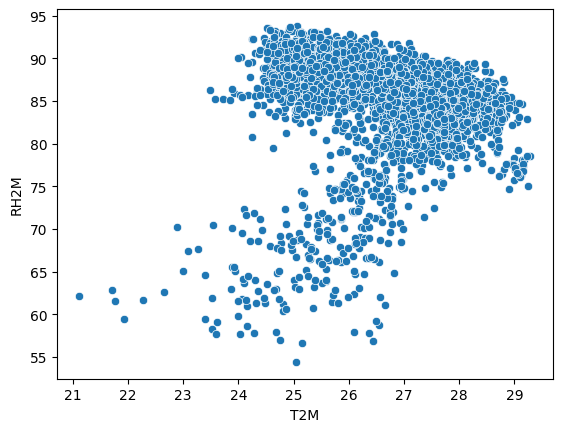

In [27]:
sns.scatterplot(data=df, x="T2M", y="RH2M")

#### Scatter Plot (Temperature range vs Windspeed)

<Axes: xlabel='T2M_RANGE', ylabel='WS2M'>

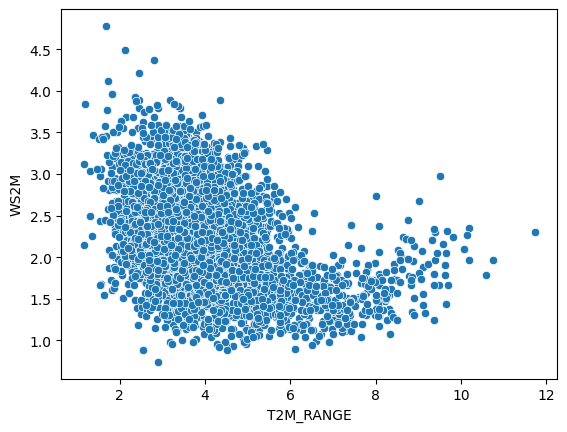

In [28]:
sns.scatterplot(data=df, x="T2M_RANGE", y="WS2M")

### Scatter Plot Insights (Temperature & Relative Humidity)
- Strong positive relationship observed between 2-meter temperature (T2M) and relative humidity (RH2M).
- Relative humidity tends to increase as temperature rises from ~25°C to 28°C.
- Highest density of points lies between T2M 24–28°C and RH2M 75–95%.
- Data forms a dense upward-sloping cloud, showing warmer conditions are associated with higher humidity.

### Scatter Plot Insights (Temperature & Wind Speed)
- Moderate positive relationship observed between 2-meter temperature (T2M_RANGE) and wind speed (WS2M).
- Wind speed tends to be higher at lower temperatures and decreases slightly as temperature rises.
- Highest density of points lies between T2M 2–8°C and WS2M 1.5–3.5 m/s.
- Data shows a broad cloud with noticeable variability, especially at lower temperature ranges.

## Distribution Analysis

#### Histogram of Prectotcorr

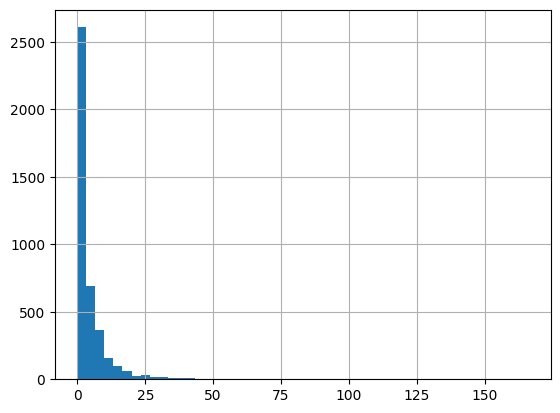

In [29]:
df["PRECTOTCORR"].hist(bins=50)
plt.show()

Highly right-skewed distribution of daily precipitation (PRECTOTCORR).
Vast majority of days have very low or zero rainfall, with a tall peak near 0 mm.

Rainfall amounts drop sharply after 5–10 mm, with very few days exceeding 20 mm.
Indicating a strong pattern of mostly dry days, interrupted by occasional moderate to heavy rain events.

#### Bubble Plot of Mean Temperature vs Relative Humidity and the size representing prectotcorr

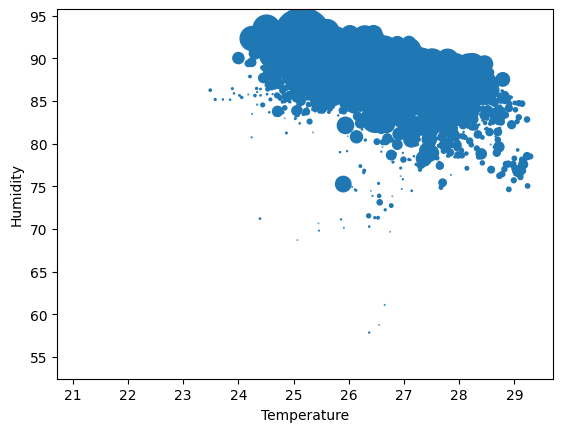

In [30]:
plt.scatter(df["T2M"], df["RH2M"], s=df["PRECTOTCORR"]*10)
plt.xlabel("Temperature")
plt.ylabel("Humidity")
plt.show()

Shows a strong positive relationship between temperature and relative humidity in Nigeria, with the densest cluster of large bubbles (heavy rainfall) occurring at higher humidity levels (80–95%) and warmer temperatures (24–29°C).  
Heavier precipitation events are clearly associated with warmer and more humid conditions.